In [1]:
from pinn_error.problems import (
    DriftDiffusion, Wave1D, Heat1DProblemSineIC, Poisson1D, Poisson2D
)

import matplotlib as mpl
import matplotlib.pyplot as plt 
import numpy as np 
import seaborn as sns 

import matplotlib.ticker as ticker 
import matplotlib.font_manager as fm

Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


In [2]:
try:
    sns.set_theme(
        style='whitegrid',
        font='Libertinus Serif',
        font_scale=2,
        rc={
            'axes.facecolor': 'white',
            'figure.facecolor': 'white',
            'mathtext.fontset': 'custom',
            'mathtext.rm': 'Libertinus Serif',
            'mathtext.it': 'Libertinus Serif:italic',
            'mathtext.bf': 'Libertinus Serif:bold',
            'text.usetex': True,
            'font.family': 'serif',
            'font.serif': ['Libertinus Serif'],
        }
    )
except Exception as e:
    print(f"Could not set custom font: {e}")
    sns.set_theme(
        style='whitegrid',
        font_scale=2,
        rc={
            'axes.facecolor': 'white',
            'figure.facecolor': 'white',
        }
    )

In [3]:
problems = {
    "Drift Diffusion": DriftDiffusion(0, 1, 1, velocity_x=2, diffusivity=0.1),
    "Wave": Wave1D(0, 1, 1, frequency=2, propagation_speed=0.5),
    "Heat": Heat1DProblemSineIC(0, 1, 1, 0.05, frequency=2),
    # "Poisson 1D": Poisson1D(0, 1),
    "Poisson 2D": Poisson2D(0, 1, 0, 1),
}

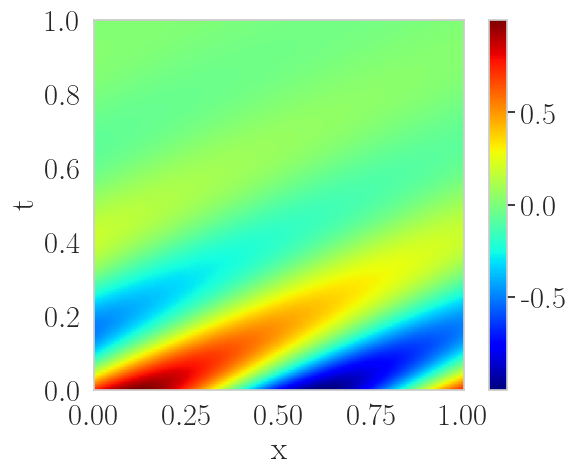

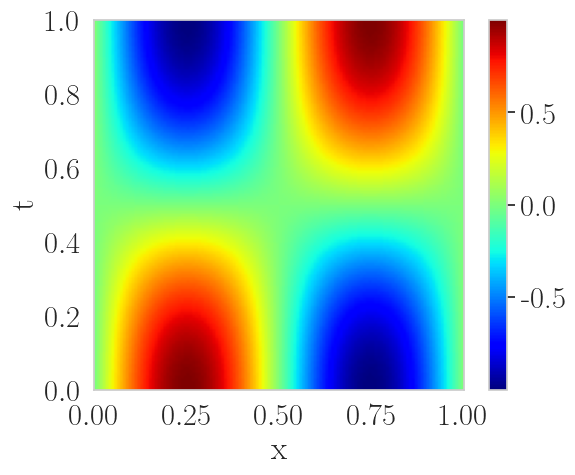

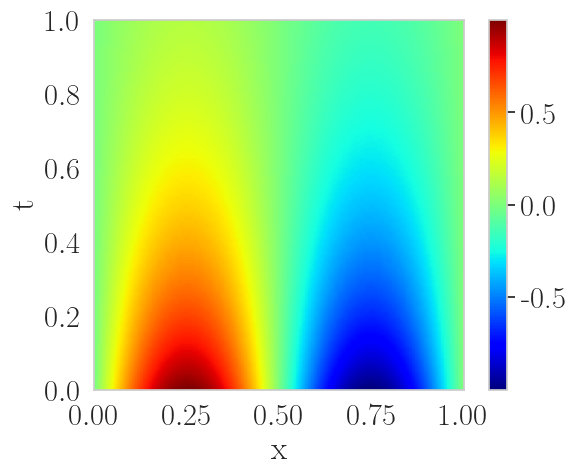

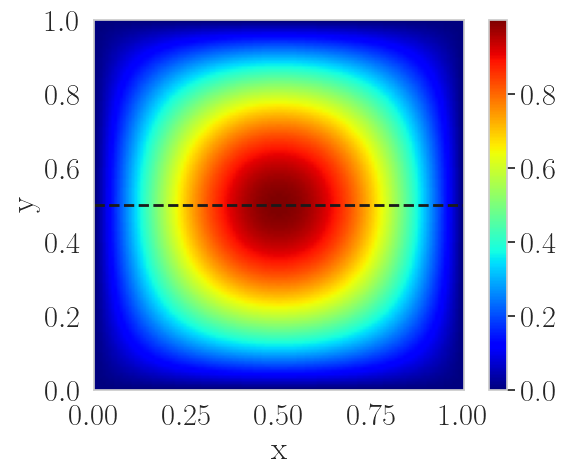

In [4]:
for problem_name, problem in problems.items():
    geom = problem.create_geometry()
    
    fig, ax = plt.subplots()
    
    n = 128  
    x1 = np.linspace(0, 1, n) 
    x2 = np.linspace(0, 1, n)
    X1, X2 = np.meshgrid(x1, x2)
    X_flat = np.stack([X1.ravel(), X2.ravel()], axis=1)
    
    u = problem.exact_solution(*X_flat.T).reshape(n, n)
    
    im = ax.imshow(u, origin='lower', extent=[x1[0], x1[-1], x2[0], x2[-1]], cmap='jet')

    # make sure colorbar only has ticks at nice round numbers
    # else this can lead to different figure sizes when saving
    cb = fig.colorbar(im, ax=ax, format='%.1f')
    cb.locator = ticker.MaxNLocator(nbins=5, steps=[1, 2, 5, 10])
    cb.update_ticks()

    # plot poisson 1D line 
    if problem_name == "Poisson 2D":
        ax.plot([0, 1], [0.5, 0.5], 'k--', linewidth=2)
    ax.grid(False)

    ax.set_xlabel('x')
    ax.set_ylabel('y')

    if problem.domain.is_time_dependent:
        ax.set_ylabel('t')

    fig.savefig(f'../figures/problems/{problem_name.lower().replace(" ", "_")}_exact_solution.pdf', bbox_inches='tight')